In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# Paths to all metric CSVs
files = {
    "sigma4": "/data/horse/ws/rabo074f-team_project/BYU2/checkpoints_dynamic_sigma4/metrics_debug.csv",
    "sigma8": "/data/horse/ws/rabo074f-team_project/BYU2/checkpoints_dynamic_sigma8/metrics_debug.csv",
    "sigma12": "/data/horse/ws/rabo074f-team_project/BYU2/checkpoints_dynamic_sigma12/metrics_debug.csv",
    "sigma16": "/data/horse/ws/rabo074f-team_project/BYU2/checkpoints_dynamic_sigma16/metrics_debug.csv",
}

In [2]:
def load_metrics(path):
    df = pd.read_csv(path)

    # Expand detection_totals JSON
    if "detection_totals" in df.columns:
        det_expanded = df["detection_totals"].apply(json.loads).apply(pd.Series)
        df = pd.concat([df, det_expanded], axis=1)

    # Expand threshold_sweep_means JSON (optional)
    if "threshold_sweep_means" in df.columns:
        try:
            thr_expanded = df["threshold_sweep_means"].apply(json.loads).apply(pd.Series)
            thr_expanded = thr_expanded.add_prefix("thr_")
            df = pd.concat([df, thr_expanded], axis=1)
        except Exception:
            pass

    if "epoch" in df.columns:
        df.sort_values("epoch", inplace=True)
        df.reset_index(drop=True, inplace=True)

    return df

# Load all sigmas
dfs = {name: load_metrics(path) for name, path in files.items()}

# Preview one
dfs["sigma4"].head()

,mode,epoch,checkpoint,train_loss,train_loss_components,val_loss,val_loss_components,mean_f2,detection_totals,voxel_totals,...,fn,fp,precision,recall,tp,thr_0.05,thr_0.10,thr_0.20,thr_0.30,thr_0.50
0,train,1,NaN,0.771871,"{""bce"": 0.2682439699059441, ""dice"": 0.99973862...",0.660706,"{""bce"": 0.15999988443923718, ""dice"": 0.9998302...",0.215269,"{""f1"": 0.0016178070073723772, ""f2"": 0.00402800...","{""fn"": 16679, ""fp"": 976370, ""tn"": 137418698, ""...",...,20.0,35773.0,0.00081,0.591837,29.0,0.000566,0.000566,0.215269,0.439394,0.439394
1,train,2,NaN,0.624024,"{""bce"": 0.12355816189850134, ""dice"": 0.9997244...",0.577389,"{""bce"": 0.0771973982001796, ""dice"": 0.99982051...",0.378788,"{""f1"": 0.0, ""f2"": 0.0, ""fn"": 49, ""fp"": 73, ""pr...","{""fn"": 16964, ""fp"": 9786, ""tn"": 138385282, ""tp...",...,49.0,73.0,0.00000,0.000000,0.0,0.000830,0.172049,0.378788,0.409091,0.439394
2,train,3,NaN,0.576338,"{""bce"": 0.07608677640498157, ""dice"": 0.9996738...",0.554363,"{""bce"": 0.05419053402588223, ""dice"": 0.9998003...",0.257576,"{""f1"": 0.0, ""f2"": 0.0, ""fn"": 49, ""fp"": 128, ""p...","{""fn"": 16964, ""fp"": 3638, ""tn"": 138391430, ""tp...",...,49.0,128.0,0.00000,0.000000,0.0,0.002552,0.022899,0.257576,0.409091,0.439394
3,train,4,NaN,0.555428,"{""bce"": 0.05525133117944712, ""dice"": 0.9995518...",0.538424,"{""bce"": 0.03822382166981697, ""dice"": 0.9997959...",0.439394,"{""f1"": 0.0, ""f2"": 0.0, ""fn"": 49, ""fp"": 0, ""pre...","{""fn"": 16964, ""fp"": 0, ""tn"": 138395068, ""tp"": 0}",...,49.0,0.0,0.00000,0.000000,0.0,0.163411,0.281987,0.439394,0.439394,0.439394
4,train,5,NaN,0.544268,"{""bce"": 0.04419460698282198, ""dice"": 0.9993417...",0.531062,"{""bce"": 0.030963577174892027, ""dice"": 0.999616...",0.439394,"{""f1"": 0.0, ""f2"": 0.0, ""fn"": 49, ""fp"": 0, ""pre...","{""fn"": 16964, ""fp"": 0, ""tn"": 138395068, ""tp"": 0}",...,49.0,0.0,0.00000,0.000000,0.0,0.108672,0.179406,0.439394,0.439394,0.439394


sigma4: Best F2 = 0.2406 at epoch 37


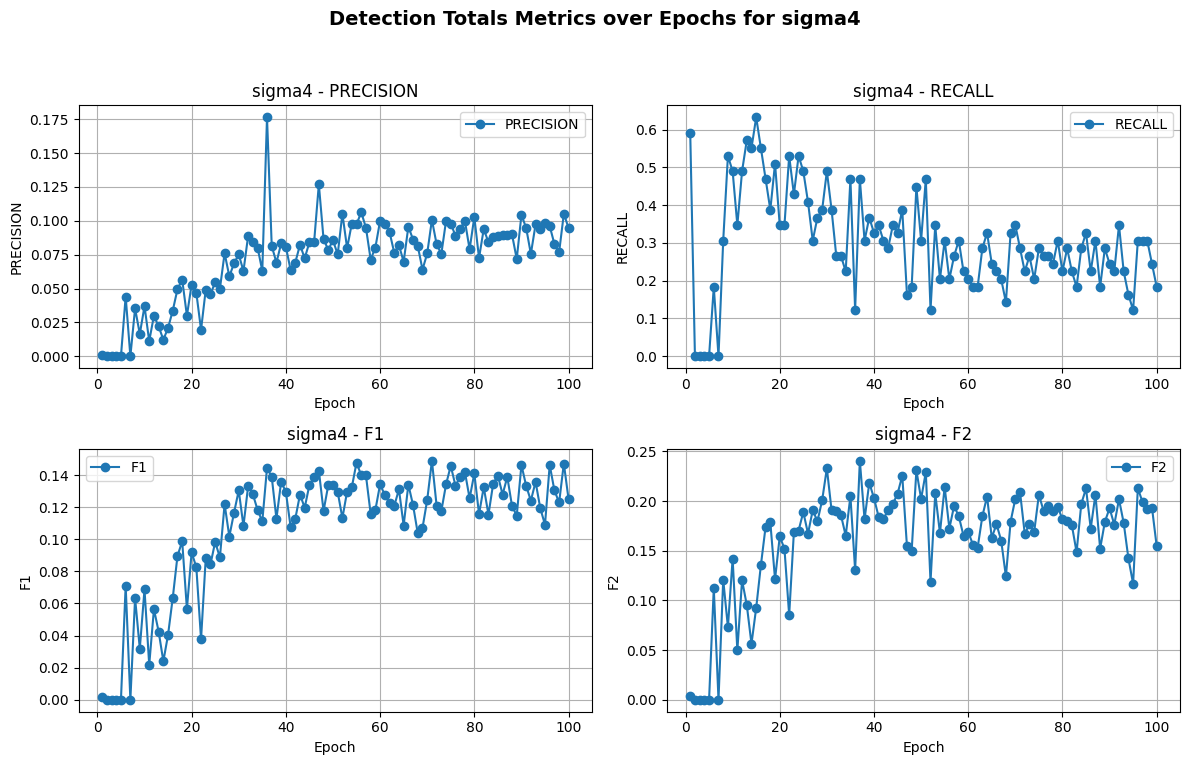

sigma8: Best F2 = 0.3196 at epoch 69


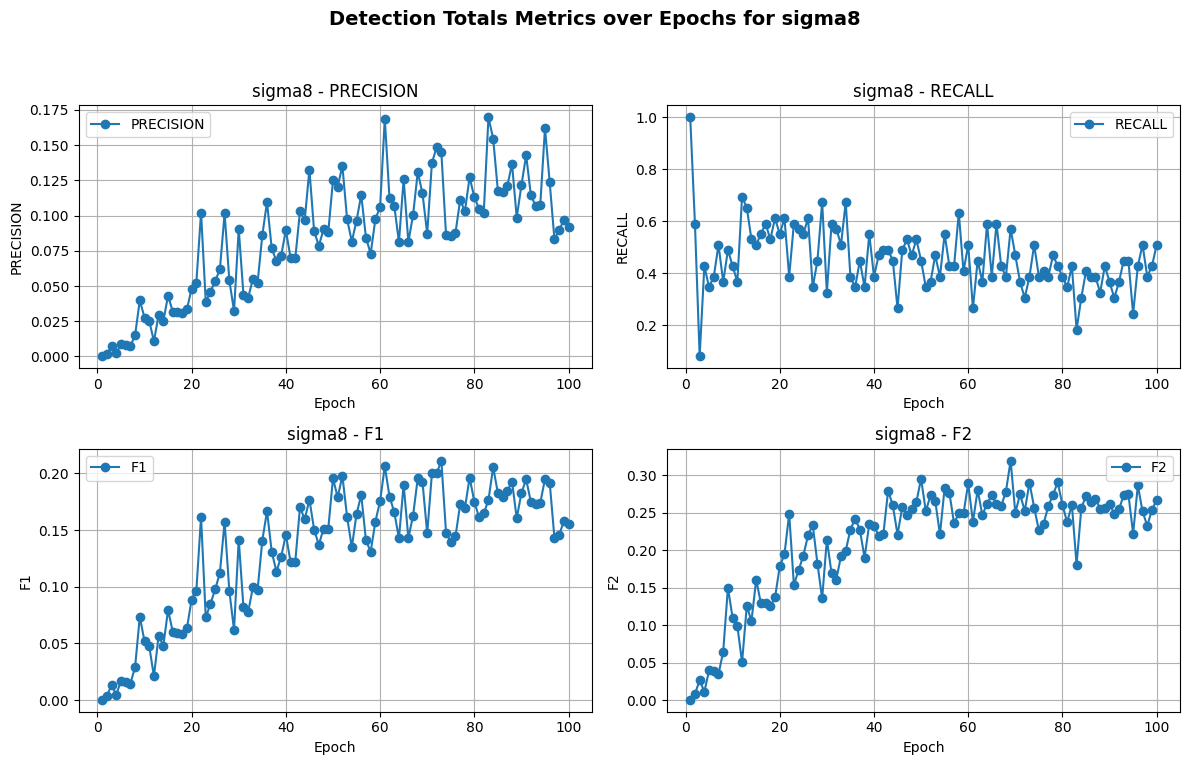

sigma12: Best F2 = 0.0863 at epoch 13


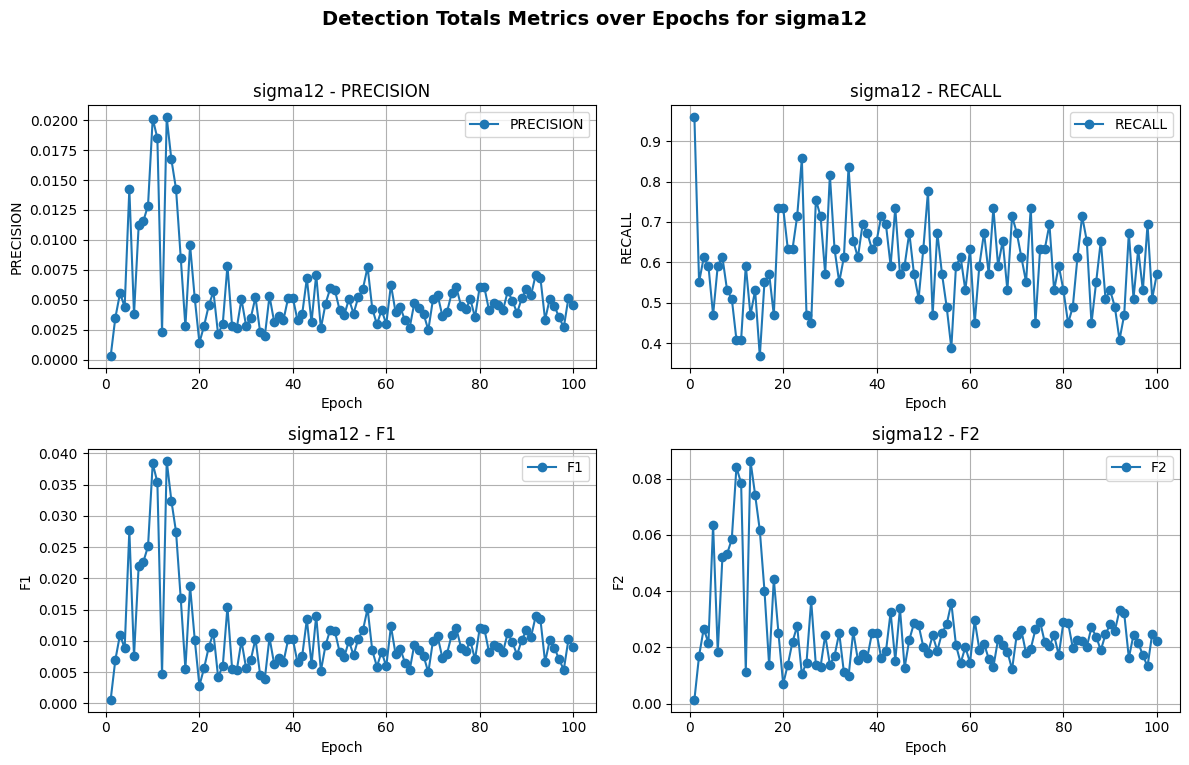

sigma16: Best F2 = 0.3253 at epoch 69


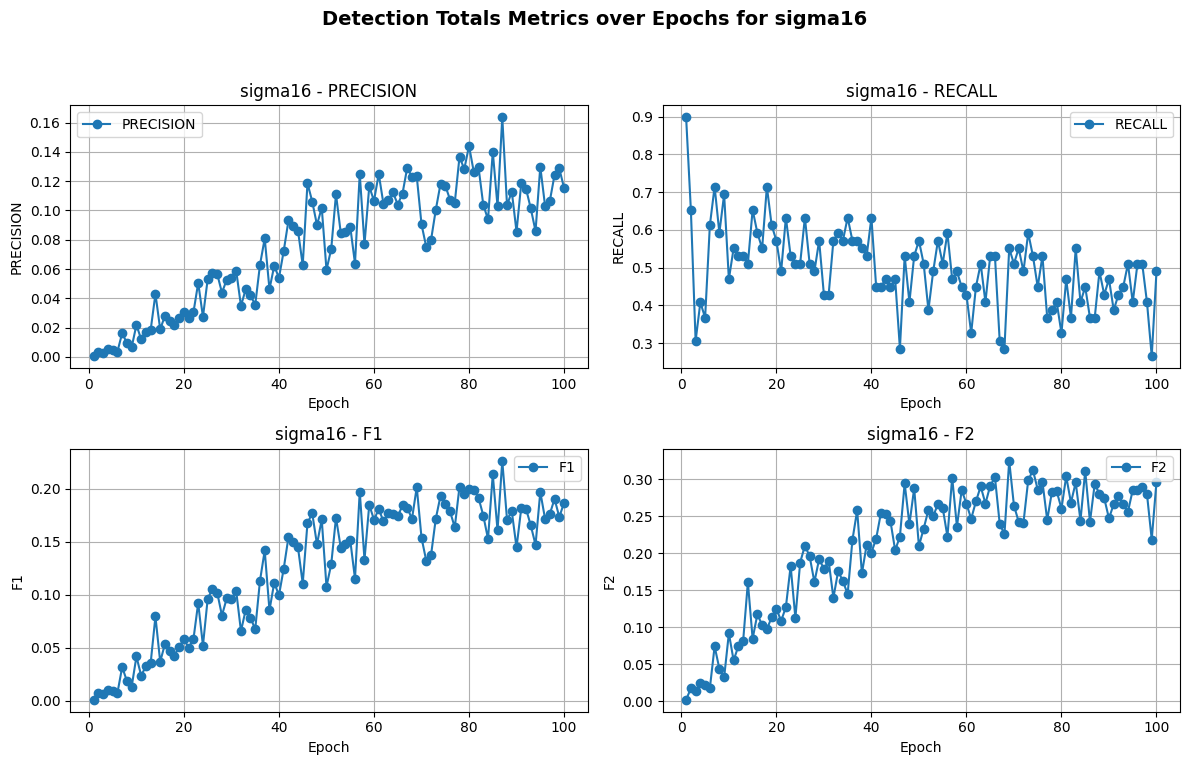

In [3]:
# Plot only detection_totals-based metrics (global/micro)
metrics = ["precision", "recall", "f1", "f2"]

for sigma, df in dfs.items():
    plt.figure(figsize=(12, 8))
    for i, metric in enumerate(metrics, 1):
        if metric in df.columns:
            plt.subplot(2, 2, i)
            plt.plot(df["epoch"], df[metric], marker="o", label=metric.upper())
            plt.xlabel("Epoch")
            plt.ylabel(metric.upper())
            plt.title(f"{sigma} - {metric.upper()}")
            plt.grid(True)
            plt.legend()
    
    # find best F2 epoch (detection_totals-based)
    if "f2" in df.columns:
        best_idx = df["f2"].idxmax()
        best_epoch = int(df.loc[best_idx, "epoch"])
        best_f2 = df.loc[best_idx, "f2"]
        print(f"{sigma}: Best F2 = {best_f2:.4f} at epoch {best_epoch}")
    
    plt.suptitle(f"Detection Totals Metrics over Epochs for {sigma}", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [4]:
for sigma, df in dfs.items():
    df["gt_count"] = df["tp"] + df["fn"]
    df["pred_count"] = df["tp"] + df["fp"]
    df["consistency"] = (df["gt_count"] == (df["tp"] + df["fn"])) & \
                        (df["pred_count"] == (df["tp"] + df["fp"]))
    df["consistency"] = df["consistency"].map({True: "OK", False: "Mismatch"})

    print(f"\n=== {sigma} - GT:Pred Matching Consistency Check ===")
    display(df[["epoch", "tp", "fp", "fn", "gt_count", "pred_count", "consistency"]].tail(10))


=== sigma4 - GT:Pred Matching Consistency Check ===


,epoch,tp,fp,fn,gt_count,pred_count,consistency
90,91,11.0,105.0,38.0,49.0,116.0,OK
91,92,17.0,208.0,32.0,49.0,225.0,OK
92,93,11.0,102.0,38.0,49.0,113.0,OK
93,94,8.0,77.0,41.0,49.0,85.0,OK
94,95,6.0,55.0,43.0,49.0,61.0,OK
95,96,15.0,141.0,34.0,49.0,156.0,OK
96,97,15.0,166.0,34.0,49.0,181.0,OK
97,98,15.0,180.0,34.0,49.0,195.0,OK
98,99,12.0,102.0,37.0,49.0,114.0,OK
99,100,9.0,86.0,40.0,49.0,95.0,OK



=== sigma8 - GT:Pred Matching Consistency Check ===


,epoch,tp,fp,fn,gt_count,pred_count,consistency
90,91,15.0,90.0,34.0,49.0,105.0,OK
91,92,18.0,139.0,31.0,49.0,157.0,OK
92,93,22.0,184.0,27.0,49.0,206.0,OK
93,94,22.0,182.0,27.0,49.0,204.0,OK
94,95,12.0,62.0,37.0,49.0,74.0,OK
95,96,21.0,149.0,28.0,49.0,170.0,OK
96,97,25.0,275.0,24.0,49.0,300.0,OK
97,98,19.0,193.0,30.0,49.0,212.0,OK
98,99,21.0,196.0,28.0,49.0,217.0,OK
99,100,25.0,247.0,24.0,49.0,272.0,OK



=== sigma12 - GT:Pred Matching Consistency Check ===


,epoch,tp,fp,fn,gt_count,pred_count,consistency
90,91,24.0,4421.0,25.0,49.0,4445.0,OK
91,92,20.0,2796.0,29.0,49.0,2816.0,OK
92,93,23.0,3354.0,26.0,49.0,3377.0,OK
93,94,33.0,9924.0,16.0,49.0,9957.0,OK
94,95,25.0,4879.0,24.0,49.0,4904.0,OK
95,96,31.0,6904.0,18.0,49.0,6935.0,OK
96,97,26.0,7349.0,23.0,49.0,7375.0,OK
97,98,34.0,12586.0,15.0,49.0,12620.0,OK
98,99,25.0,4814.0,24.0,49.0,4839.0,OK
99,100,28.0,6089.0,21.0,49.0,6117.0,OK



=== sigma16 - GT:Pred Matching Consistency Check ===


,epoch,tp,fp,fn,gt_count,pred_count,consistency
90,91,19.0,141.0,30.0,49.0,160.0,OK
91,92,21.0,162.0,28.0,49.0,183.0,OK
92,93,22.0,195.0,27.0,49.0,217.0,OK
93,94,25.0,266.0,24.0,49.0,291.0,OK
94,95,20.0,134.0,29.0,49.0,154.0,OK
95,96,25.0,217.0,24.0,49.0,242.0,OK
96,97,25.0,210.0,24.0,49.0,235.0,OK
97,98,20.0,141.0,29.0,49.0,161.0,OK
98,99,13.0,88.0,36.0,49.0,101.0,OK
99,100,24.0,184.0,25.0,49.0,208.0,OK


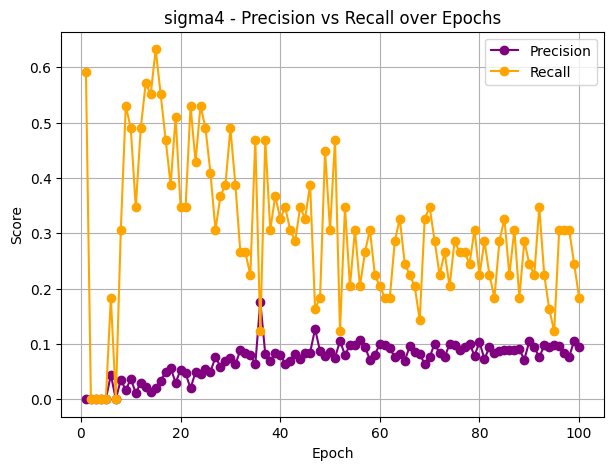

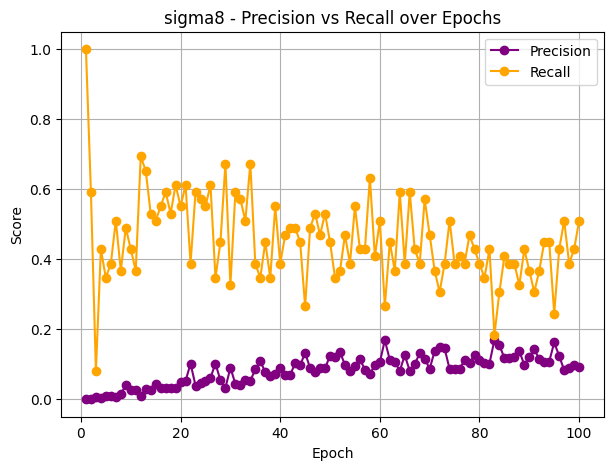

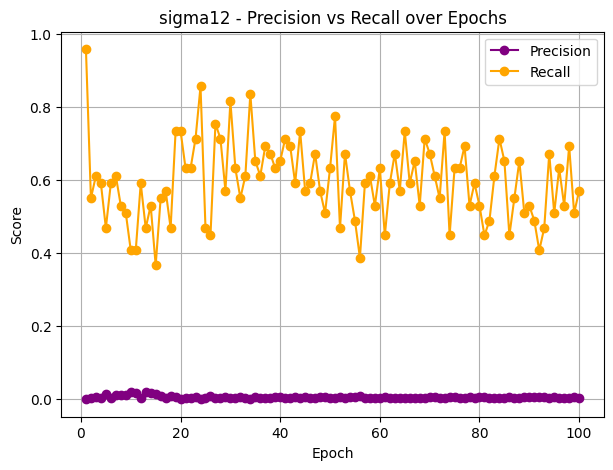

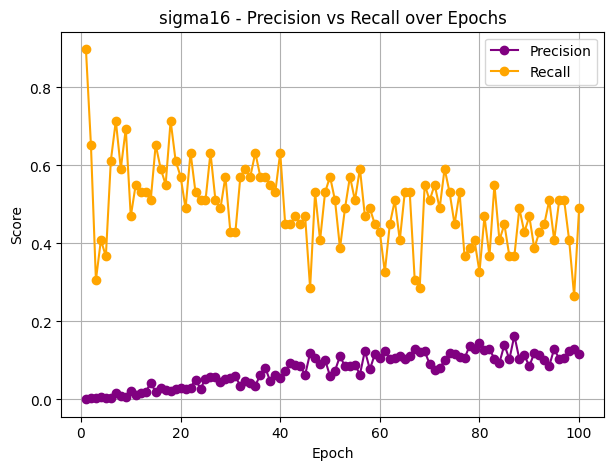

In [5]:
# Inspect precision vs. recall
for sigma, df in dfs.items():
    plt.figure(figsize=(7,5))
    plt.plot(df["epoch"], df["precision"], marker="o", label="Precision", color="purple")
    plt.plot(df["epoch"], df["recall"], marker="o", label="Recall", color="orange")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{sigma} - Precision vs Recall over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()